# Notebook 03: Pathway Enrichment (Reproduction)

Using the DE results from notebook 02, test whether GSEA recovers the pathway-level findings reported by Conti et al. 

This is the critical test for the GE_ANAK_vs_GE comparison specifically. Notebook 02 found 0 individually significant genes at both timepoints (confirmed independent of our filtering choice), but the paper reports a clear pathway-level effect for this exact comparison. GSEA, which uses the full ranked gene list rather than a significance cutoff, is the right tool to check whether that coordinated signal is recoverable here.

In [1]:
import pandas as pd
import re

from hspc_response.io import load_config, resolve_path
from hspc_response.enrichment import run_gsea_prerank
from hspc_response.plotting import plot_gsea_dotplot

## Load DE results

Loads the six DE result tables (three contrasts x two timepoints) saved from notebook 02, to use as input for GSEA.

In [2]:
config = load_config()

tables_dir = resolve_path(config["paths"]["tables_dir"])

# Load all six DE result tables (2 timepoints x 3 contrasts) into a dictionary
results = {}
for timepoint in config["design"]["timepoints"]:
    for contrast_cfg in config["design"]["contrasts"]:
        name = contrast_cfg["name"]
        path = tables_dir / f"{timepoint}_{name}.csv"
        results[(timepoint, name)] = pd.read_csv(path, index_col=0)

# Confirm all six tables loaded with expected shapes
for key, df in results.items():
    print(key, df.shape)

('24h', 'GE_vs_RNP_NEG') (16907, 7)
('24h', 'GE_ANAK_vs_GE') (16907, 7)
('24h', 'GE_ANAK_vs_RNP_NEG') (16907, 7)
('96h', 'GE_vs_RNP_NEG') (20536, 7)
('96h', 'GE_ANAK_vs_GE') (20536, 7)
('96h', 'GE_ANAK_vs_RNP_NEG') (20536, 7)


## Check for duplicate gene symbols before ranking

In [3]:
# Confirm no duplicate gene symbols in any of the six result tables before ranking genes for GSEA

for (timepoint, name), df in results.items():
    n_dupes = df.index.duplicated().sum()
    if n_dupes > 0:
        print(f"{timepoint} | {name}: {n_dupes} duplicate gene symbols")
    else:
        print(f"{timepoint} | {name}: no duplicates")

24h | GE_vs_RNP_NEG: no duplicates
24h | GE_ANAK_vs_GE: no duplicates
24h | GE_ANAK_vs_RNP_NEG: no duplicates
96h | GE_vs_RNP_NEG: no duplicates
96h | GE_ANAK_vs_GE: no duplicates
96h | GE_ANAK_vs_RNP_NEG: no duplicates


## GSEA: does the Anakinra effect show up at the pathway level (96h)?

This tests the GE_ANAK_vs_GE comparison at 96h against Hallmark gene sets, ranked by log2FoldChange (matching the paper's method exactly). This is the direct test of whether the paper's reported pathway-level Anakinra effect (downregulation of IFN-alpha/gamma response and NF-κB-related inflammatory pathways, per Figure 5B) is recoverable here, despite zero individually significant genes in the DE step.

In [4]:
# Run GSEA on GE_ANAK_vs_GE at 96h, ranked by log2FoldChange, using the Hallmark library specified in config
gsea_96h_anak = run_gsea_prerank(
    results[("96h", "GE_ANAK_vs_GE")],
    gene_sets=config["enrichment"]["reproduction"]["libraries"]["Hallmark"],
    ranking_col=config["enrichment"]["reproduction"]["ranking_metric"],
    permutation_num=config["enrichment"]["gsea_permutations"],
)

gsea_96h_anak["FDR q-val"] = gsea_96h_anak["FDR q-val"].astype(float)
gsea_96h_anak["NES"] = gsea_96h_anak["NES"].astype(float)

n_sig = (gsea_96h_anak["FDR q-val"] < 0.05).sum()
print(f"96h GE_ANAK_vs_GE: {len(gsea_96h_anak)} terms tested, {n_sig} significant (FDR<0.05)")


# Keyword-based matching to find the paper's five specifically named pathways (e.g. "TNF-alpha" vs "TNFA")
pathway_keywords = {
    "Interferon Alpha Response": ["interferon", "alpha"],
    "Interferon Gamma Response": ["interferon", "gamma"],
    "TNF-alpha Signaling via NF-kB": ["tnf", "nf"],
    "IL-2/STAT5 Signaling": ["il-2", "stat5"],
    "IL-6/JAK/STAT3 Signaling": ["il-6", "stat3"],
}

def matches_pathway(term, keywords):
    term_lower = term.lower()
    return all(kw.lower() in term_lower for kw in keywords)

matched_rows = []
for pathway_name, keywords in pathway_keywords.items():
    hits = gsea_96h_anak[gsea_96h_anak["Term"].apply(lambda t: matches_pathway(t, keywords))]
    matched_rows.append(hits)

matched = pd.concat(matched_rows).drop_duplicates()
print("\nPaper's specific reported pathways (Figure 5B):")
print(matched[["Term", "NES", "FDR q-val"]].to_string(index=False))

96h GE_ANAK_vs_GE: 49 terms tested, 0 significant (FDR<0.05)

Paper's specific reported pathways (Figure 5B):
                         Term       NES  FDR q-val
    Interferon Alpha Response -0.862455   1.000000
    Interferon Gamma Response -0.874257   1.000000
TNF-alpha Signaling via NF-kB -0.910535   1.000000
         IL-2/STAT5 Signaling -1.199482   0.795885
     IL-6/JAK/STAT3 Signaling -1.039351   1.000000


## GSEA: does the Anakinra effect show up at the pathway level at 24h?

This repeats the same GSEA analysis for the GE_ANAK_vs_GE comparison at 24h, checking whether the same directionally-consistent pattern seen at 96h holds, strengthens, or weakens at the earlier timepoint. Note that at 24h, we also saw 0 significant genes. 

In [5]:
# Run GSEA on GE_ANAK_vs_GE at 24h, same method and libraries as 96h
gsea_24h_anak = run_gsea_prerank(
    results[("24h", "GE_ANAK_vs_GE")],
    gene_sets=config["enrichment"]["reproduction"]["libraries"]["Hallmark"],
    ranking_col=config["enrichment"]["reproduction"]["ranking_metric"],
    permutation_num=config["enrichment"]["gsea_permutations"],
)

gsea_24h_anak["FDR q-val"] = gsea_24h_anak["FDR q-val"].astype(float)
gsea_24h_anak["NES"] = gsea_24h_anak["NES"].astype(float)

n_sig = (gsea_24h_anak["FDR q-val"] < 0.05).sum()
print(f"24h GE_ANAK_vs_GE: {len(gsea_24h_anak)} terms tested, {n_sig} significant (FDR<0.05)")

# Reuse the same pathway_keywords and matches_pathway defined for 96h
matched_rows_24h = []
for pathway_name, keywords in pathway_keywords.items():
    hits = gsea_24h_anak[gsea_24h_anak["Term"].apply(lambda t: matches_pathway(t, keywords))]
    matched_rows_24h.append(hits)

matched_24h = pd.concat(matched_rows_24h).drop_duplicates()
print("\nPaper's specific reported pathways (Figure 5B) at 24h:")
print(matched_24h[["Term", "NES", "FDR q-val"]].to_string(index=False))

24h GE_ANAK_vs_GE: 49 terms tested, 0 significant (FDR<0.05)

Paper's specific reported pathways (Figure 5B) at 24h:
                         Term       NES  FDR q-val
    Interferon Alpha Response -0.766371        1.0
    Interferon Gamma Response  0.698879        1.0
TNF-alpha Signaling via NF-kB -1.019760        1.0
         IL-2/STAT5 Signaling -0.744320        1.0
     IL-6/JAK/STAT3 Signaling -0.880906        1.0


## Reproducing Conti et al.'s Figure 5B directly: all 35 Hallmark terms, no significance filter

Re-examining the authors' own R code for this exact comparison (GE_ANAK vs. GE) shows they did not apply a significance filter here. They plotted raw NES values for a fixed list of 35 Hallmark terms directly. This replicates that approach exactly. 
- Same 35 terms
- No FDR cutoff
- Comparing NES direction and magnitude to the paper's reported result


In [6]:
# The 35 Hallmark terms specifically named in the authors' own R code for this comparison (Figure 5B), with no significance filter applied to them

hallmark_terms_paper = [
    "KRAS_SIGNALING_UP", "ESTROGEN_RESPONSE_LATE", "MYOGENESIS", "EPITHELIAL_MESENCHYMAL_TRANSITION", "ANGIOGENESIS",
    "COAGULATION", "HEDGEHOG_SIGNALING", "IL6_JAK_STAT3_SIGNALING", "TNFA_SIGNALING_VIA_NFKB", "IL2_STAT5_SIGNALING",
    "INTERFERON_ALPHA_RESPONSE", "INTERFERON_GAMMA_RESPONSE", "MYC_TARGETS_V2", "MITOTIC_SPINDLE", "DNA_REPAIR",
    "UNFOLDED_PROTEIN_RESPONSE", "G2M_CHECKPOINT", "E2F_TARGETS", "MTORC1_SIGNALING", "MYC_TARGETS_V1", "APICAL_JUNCTION",
    "UV_RESPONSE_UP", "APOPTOSIS", "REACTIVE_OXYGEN_SPECIES_PATHWAY", "ESTROGEN_RESPONSE_EARLY", "P53_PATHWAY",
    "ALLOGRAFT_REJECTION", "XENOBIOTIC_METABOLISM", "PROTEIN_SECRETION", "OXIDATIVE_PHOSPHORYLATION", "HEME_METABOLISM",
    "UV_RESPONSE_DN", "INFLAMMATORY_RESPONSE", "COMPLEMENT", "BILE_ACID_METABOLISM", "KRAS_SIGNALING_DN",
]

def normalize_for_matching(term):
    """Strip Hallmark prefix and non-alphanumeric characters, uppercase, for
    loose matching against the paper's own term naming (which differs in
    punctuation from gseapy's output)."""
    term = re.sub(r"^MSigDB_Hallmark_2020__", "", term)
    return re.sub(r"[^A-Za-z0-9]", "", term).upper()

paper_terms_normalized = {normalize_for_matching(t): t for t in hallmark_terms_paper}

def get_matching_results(gsea_df, timepoint_label):
    gsea_df = gsea_df.copy()
    gsea_df["Term_norm"] = gsea_df["Term"].apply(normalize_for_matching)
    matched = gsea_df[gsea_df["Term_norm"].isin(paper_terms_normalized.keys())].copy()
    matched["Timepoint"] = timepoint_label
    return matched[["Term", "NES", "NOM p-val", "FDR q-val", "Timepoint"]]
    
# Match both timepoints' GSEA results against the paper's fixed 35-term list
combined = pd.concat([
    get_matching_results(gsea_24h_anak, "24h"),
    get_matching_results(gsea_96h_anak, "96h"),
])

print(f"Matched {combined['Term'].nunique()} of {len(hallmark_terms_paper)} paper-specified Hallmark terms")
print()
print(combined.sort_values(["Term", "Timepoint"]).to_string(index=False))

Matched 35 of 36 paper-specified Hallmark terms

                             Term       NES  NOM p-val  FDR q-val Timepoint
              Allograft Rejection  0.968413   0.532448   1.000000       24h
              Allograft Rejection -0.665587   0.996667   1.000000       96h
                     Angiogenesis -0.823657   0.742529   1.000000       24h
                     Angiogenesis -0.674785   0.884826   1.000000       96h
                  Apical Junction  0.638224   0.998440   1.000000       24h
                  Apical Junction -0.936118   0.592199   1.000000       96h
                        Apoptosis  0.607033   0.998454   1.000000       24h
                        Apoptosis -0.470590   1.000000   1.000000       96h
             Bile Acid Metabolism  0.907576   0.619863   1.000000       24h
             Bile Acid Metabolism -0.518843   0.998192   1.000000       96h
                      Coagulation  0.789491   0.868637   1.000000       24h
                      Coagulation -1.21

## Core reproduction: GE_vs_RNP_NEG (Hallmark, full set)

This tests the primary editing-induced effect (GE vs RNP_NEG) against the full Hallmark library at both timepoints, following the authors' approach of filtering to significant terms (FDR<0.05) for this comparison. The full unfiltered ranking is also reported for a complete directional picture. Senescence-specific gene sets (SenMayo, Purcell, Pribluda, Sencan, SASP_SCHLEICH) are not included in this analysis. 

In [7]:
# Run GSEA for the core editing effect (GE vs RNP_NEG) at 24h against the full Hallmark library
gsea_24h_ge = run_gsea_prerank(
    results[("24h", "GE_vs_RNP_NEG")],
    gene_sets=config["enrichment"]["reproduction"]["libraries"]["Hallmark"],
    ranking_col=config["enrichment"]["reproduction"]["ranking_metric"],
    permutation_num=config["enrichment"]["gsea_permutations"],
)
gsea_24h_ge["FDR q-val"] = gsea_24h_ge["FDR q-val"].astype(float)
gsea_24h_ge["NES"] = gsea_24h_ge["NES"].astype(float)

n_pos = (gsea_24h_ge["NES"] > 0).sum()
n_neg = (gsea_24h_ge["NES"] < 0).sum()
n_sig = (gsea_24h_ge["FDR q-val"] < 0.05).sum()

print(f"24h GE_vs_RNP_NEG")
print(f"Overall direction: {n_neg}/{len(gsea_24h_ge)} negative NES, {n_pos}/{len(gsea_24h_ge)} positive NES")
print(f"Significant (FDR<0.05): {n_sig}/{len(gsea_24h_ge)}")

# Show only the significant terms, sorted by NES
print(f"\n-- Significant terms only (FDR<0.05) --")
sig_24h = gsea_24h_ge[gsea_24h_ge["FDR q-val"] < 0.05].sort_values("NES")
print(sig_24h[["Term", "NES", "FDR q-val"]].to_string(index=False))

24h GE_vs_RNP_NEG
Overall direction: 13/49 negative NES, 36/49 positive NES
Significant (FDR<0.05): 13/49

-- Significant terms only (FDR<0.05) --
                             Term       NES  FDR q-val
                      E2F Targets -2.335262   0.000000
                  G2-M Checkpoint -2.146177   0.000000
                   Myc Targets V1 -2.125087   0.000000
                   Myc Targets V2 -1.669862   0.009872
                     Angiogenesis  1.630577   0.014215
                          Hypoxia  1.794599   0.001791
         IL-6/JAK/STAT3 Signaling  1.832735   0.001170
                       Myogenesis  1.874565   0.000853
                        Apoptosis  1.908642   0.000409
            Inflammatory Response  2.063696   0.000256
Epithelial Mesenchymal Transition  2.072692   0.000000
    TNF-alpha Signaling via NF-kB  2.387872   0.000000
                      p53 Pathway  2.559796   0.000000


In [8]:
# Show the full ranking (all terms, no significance filter) for a complete directional picture
print(f"-- 24h: All terms, sorted by NES (no significance filter) --")
print(gsea_24h_ge.sort_values("NES")[["Term", "NES", "FDR q-val"]].to_string(index=False))

-- 24h: All terms, sorted by NES (no significance filter) --
                             Term       NES  FDR q-val
                      E2F Targets -2.335262   0.000000
                  G2-M Checkpoint -2.146177   0.000000
                   Myc Targets V1 -2.125087   0.000000
                   Myc Targets V2 -1.669862   0.009872
                Protein Secretion -1.253562   0.222825
                  Mitotic Spindle -1.119286   0.461476
                   UV Response Dn -0.960442   1.000000
                Androgen Response -0.897751   1.000000
               TGF-beta Signaling -0.893961   1.000000
                  heme Metabolism -0.875962   0.995379
                  Spermatogenesis -0.820605   1.000000
       Wnt-beta Catenin Signaling -0.786695   0.991743
        Oxidative Phosphorylation -0.567930   0.996890
                      Pperoxisome  0.506000   0.998749
         PI3K/AKT/mTOR  Signaling  0.672781   1.000000
        Unfolded Protein Response  0.690176   1.000000
    

In [9]:
# Run GSEA for the core editing effect (GE vs RNP_NEG) at 96h, same method as the 24h
gsea_96h_ge = run_gsea_prerank(
    results[("96h", "GE_vs_RNP_NEG")],
    gene_sets=config["enrichment"]["reproduction"]["libraries"]["Hallmark"],
    ranking_col=config["enrichment"]["reproduction"]["ranking_metric"],
    permutation_num=config["enrichment"]["gsea_permutations"],
)
gsea_96h_ge["FDR q-val"] = gsea_96h_ge["FDR q-val"].astype(float)
gsea_96h_ge["NES"] = gsea_96h_ge["NES"].astype(float)

n_pos = (gsea_96h_ge["NES"] > 0).sum()
n_neg = (gsea_96h_ge["NES"] < 0).sum()
n_sig = (gsea_96h_ge["FDR q-val"] < 0.05).sum()

print(f"96h GE_vs_RNP_NEG")
print(f"Overall direction: {n_neg}/{len(gsea_96h_ge)} negative NES, {n_pos}/{len(gsea_96h_ge)} positive NES")
print(f"Significant (FDR<0.05): {n_sig}/{len(gsea_96h_ge)}")

print(f"\n-- Significant terms only (FDR<0.05) --")
sig_96h = gsea_96h_ge[gsea_96h_ge["FDR q-val"] < 0.05].sort_values("NES")
print(sig_96h[["Term", "NES", "FDR q-val"]].to_string(index=False))

96h GE_vs_RNP_NEG
Overall direction: 19/49 negative NES, 30/49 positive NES
Significant (FDR<0.05): 6/49

-- Significant terms only (FDR<0.05) --
                         Term       NES  FDR q-val
                  E2F Targets -1.755393   0.024053
               Myc Targets V1 -1.710551   0.020846
               Myc Targets V2 -1.594974   0.040088
                  p53 Pathway  1.529794   0.048774
           Hedgehog Signaling  1.761963   0.004441
TNF-alpha Signaling via NF-kB  1.783053   0.005653


In [10]:
# Show the full ranking (all terms, no significance filter) for a complete directional picture
print(f"-- 96h: All terms, sorted by NES (no significance filter) --")
print(gsea_96h_ge.sort_values("NES")[["Term", "NES", "FDR q-val"]].to_string(index=False))

-- 96h: All terms, sorted by NES (no significance filter) --
                             Term       NES  FDR q-val
                      E2F Targets -1.755393   0.024053
                   Myc Targets V1 -1.710551   0.020846
                   Myc Targets V2 -1.594974   0.040088
        Oxidative Phosphorylation -1.365720   0.186007
                  G2-M Checkpoint -1.319263   0.219040
                  heme Metabolism -1.280466   0.237587
               TGF-beta Signaling -1.173349   0.411644
                 mTORC1 Signaling -1.101885   0.582275
                Protein Secretion -1.072981   0.621450
                  Apical Junction -1.059253   0.606448
            Fatty Acid Metabolism -1.050036   0.586885
                   Apical Surface -0.969186   0.841843
                Androgen Response -0.942001   0.877120
                   UV Response Dn -0.928998   0.856847
           Estrogen Response Late -0.882493   0.942437
          Cholesterol Homeostasis -0.878409   0.893556
    

## Interpretation: GE_vs_RNP_NEG, core editing effect, strongly reproduced

This is the paper's central, headline finding, and this independent reanalysis reproduces it cleanly. All five of the paper's specifically named pathways show the correct direction **and** reach FDR<0.05 significance:

| Pathway | NES (24h) | FDR (24h) | NES (96h) | FDR (96h) |
|---|---|---|---|---|
| p53 Pathway | +2.56 | <0.001 | +1.53 | 0.049 |
| TNF-alpha Signaling via NF-kB | +2.39 | <0.001 | +1.78 | 0.006 |
| Myc Targets V1 | -2.13 | <0.001 | -1.71 | 0.021 |
| Myc Targets V2 | -1.67 | 0.010 | -1.59 | 0.040 |
| E2F Targets | -2.34 | <0.001 | -1.76 | 0.024 |

All five reproduce at both timepoints, with effect sizes and significance generally strongest at 24h and somewhat weakens (still significant) by 96h.

This is a strong, direct confirmation of the paper's core claim, independently verified using a different implementation stack (Python/pydeseq2/gseapy vs. the original R/DESeq2/clusterProfiler pipeline) and independently-made filtering and QC decisions. It also provides important context for the weaker Anakinra rescue reproduction. The overall pipeline is clearly capable of detecting a strong, real biological signal correctly, which strengthens confidence that the more modest Anakinra findings reflect a genuinely subtler effect rather than a methodological failure.

## Note: senescence-specific gene sets not included

The paper's Figure 1I additionally shows five literature-curated senescence gene sets (SenMayo, Purcell, Pribluda_SENESCENCE_INFLAMMATORY_GENES, Sencan, SASP_SCHLEICH). These were not readily available as standalone downloadable gene sets (only SenMayo was confirmed in MSigDB) and were not pursued further, as the core reproduction above (Hallmark pathways) already independently confirms the paper's headline finding. This is a scoped limitation of this reproduction.

In [11]:
# Save enrichment results
enrichment_dir = resolve_path(config["paths"]["tables_dir"]) / "enrichment"
enrichment_dir.mkdir(parents=True, exist_ok=True)

gsea_24h_ge.to_csv(enrichment_dir / "gsea_24h_GE_vs_RNP_NEG.csv", index=False)
gsea_96h_ge.to_csv(enrichment_dir / "gsea_96h_GE_vs_RNP_NEG.csv", index=False)
gsea_24h_anak.to_csv(enrichment_dir / "gsea_24h_GE_ANAK_vs_GE.csv", index=False)
gsea_96h_anak.to_csv(enrichment_dir / "gsea_96h_GE_ANAK_vs_GE.csv", index=False)

print("Saved 4 GSEA result tables to", enrichment_dir)

Saved 4 GSEA result tables to /Users/kim/Desktop/Projects-Programming/hspc-rnaseq-gene-editing-response/results/tables/enrichment


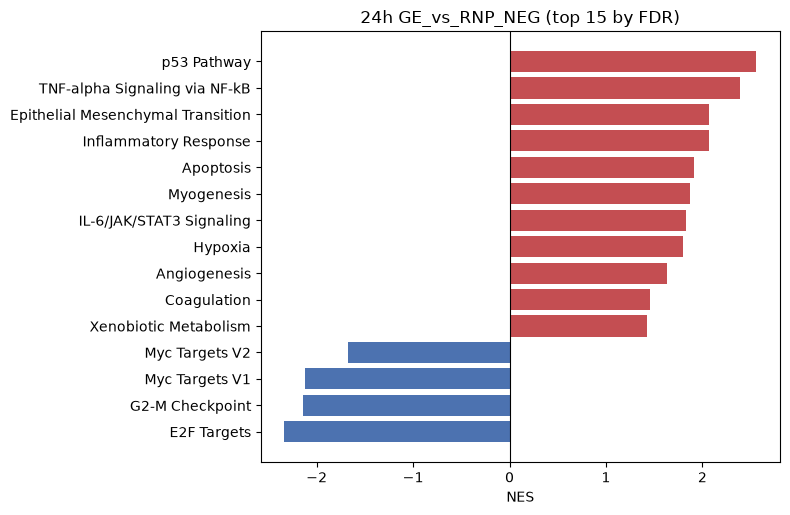

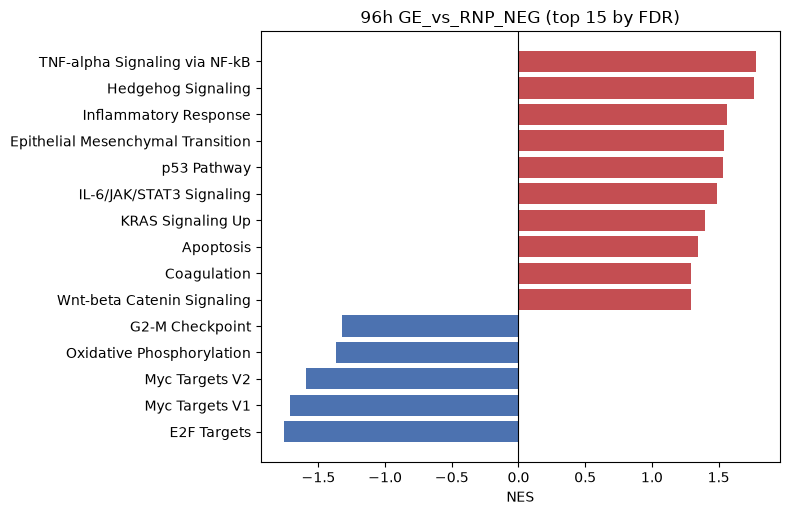

In [12]:
# Plot results 
plot_gsea_dotplot(gsea_24h_ge, title="24h GE_vs_RNP_NEG (top 15 by FDR)",
                   save_path=resolve_path("results/figures/gsea_dotplot_24h_ge.png"))
plot_gsea_dotplot(gsea_96h_ge, title="96h GE_vs_RNP_NEG (top 15 by FDR)",
                   save_path=resolve_path("results/figures/gsea_dotplot_96h_ge.png"))